# 00 Field1/Field2 Sign Data Audit

이번 07 파트는 표지판 탐지 모델(YOLO)을 만드는 흐름이다.

레인 모델과 다르게, YOLO 표지판 모델은 폴더명만으로 학습할 수 없다.  
YOLO는 이미지 안에서 표지판 위치를 `bounding box`로 찍어야 하므로, Roboflow/CVAT/Label Studio 같은 object detection 라벨링 도구가 필요하다.

이 00 노트북의 목적은 라벨링 전에 다음을 확인하는 것이다.

1. field1/field2 표지판 데이터가 어디에 있고 몇 장인지 파악한다.
2. 학습 대상 6클래스와 제외/참고 데이터를 분리한다.
3. Roboflow 업로드용 후보 manifest를 만든다.
4. 클래스별 샘플 그리드를 저장해서 실제로 표지판이 보이는지 빠르게 확인한다.

최종 YOLO 클래스는 아래 6개로 고정한다.

```text
left / right / straight / horn / stop / speed_20
```

`red`, `green`은 표지판 6클래스가 아니라 신호등 쪽 데이터이므로 이번 YOLO 표지판 모델의 직접 클래스에는 넣지 않는다.

## 0. 경로와 실행 설정

이 노트북은 local VSCode `<env>` kernel에서 실행한다.  
결과는 `review_outputs/00_data_audit` 아래에 저장한다.

In [1]:
from pathlib import Path
import os
import re
import csv
import json
import shutil
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '07_sign_detection_yolo'

FIELD1_SIGNS_ROOT = PROJECT_ROOT / '10_experiments' / '02_field1_map_lab' / 'data' / '20260430_map_lab' / 'raw' / 'signs'
FIELD2_RAW_ROOT = PROJECT_ROOT / '10_experiments' / '04_field2_map_lab' / 'field2_experiment' / 'data' / '20260501_field2' / 'raw'
FIELD2_SIGNS_ROOT = FIELD2_RAW_ROOT / '06_sign_capture_drive'
FIELD2_TRAFFIC_ROOT = FIELD2_RAW_ROOT / '07_traffic_capture'

REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '00_data_audit'
TABLE_DIR = REVIEW_ROOT / 'tables'
GRID_DIR = REVIEW_ROOT / 'sample_grids'
for p in [EXP_ROOT / 'notebooks', REVIEW_ROOT, TABLE_DIR, GRID_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SIGN_CLASSES = ['left', 'right', 'straight', 'horn', 'stop', 'speed_20']
TRAFFIC_CLASSES = ['red', 'green']
BACKGROUND_NAMES = ['background']
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

RANDOM_SEED = 0
SAMPLES_PER_GROUP = 12


def win_long_path(path):
    p = Path(path)
    s = str(p if p.is_absolute() else p.resolve())
    if os.name == 'nt' and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s


def cv2_imread_color(path):
    data = np.fromfile(win_long_path(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def cv2_imwrite(path, image):
    ok, encoded = cv2.imencode(Path(path).suffix or '.jpg', image)
    if not ok:
        raise RuntimeError(f'failed to encode image: {path}')
    encoded.tofile(win_long_path(path))


print('EXP_ROOT:', EXP_ROOT)
print('FIELD1_SIGNS_ROOT:', FIELD1_SIGNS_ROOT, FIELD1_SIGNS_ROOT.exists())
print('FIELD2_SIGNS_ROOT:', FIELD2_SIGNS_ROOT, FIELD2_SIGNS_ROOT.exists())
print('FIELD2_TRAFFIC_ROOT:', FIELD2_TRAFFIC_ROOT, FIELD2_TRAFFIC_ROOT.exists())

assert FIELD1_SIGNS_ROOT.exists(), FIELD1_SIGNS_ROOT
assert FIELD2_SIGNS_ROOT.exists(), FIELD2_SIGNS_ROOT
assert FIELD2_TRAFFIC_ROOT.exists(), FIELD2_TRAFFIC_ROOT

EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo
FIELD1_SIGNS_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\02_field1_map_lab\data\20260430_map_lab\raw\signs True
FIELD2_SIGNS_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\raw\06_sign_capture_drive True
FIELD2_TRAFFIC_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\raw\07_traffic_capture True


## 1. 데이터 소스 정의

이번 표지판 YOLO에서 직접 라벨링할 후보는 다음이다.

- field1 `raw/signs/{left,right,straight,horn,stop,speed_20}`
- field2 `raw/06_sign_capture_drive/{left,right,straight,horn,stop,speed_20}`

아래는 별도 취급한다.

- field1 `raw/signs/background`: negative/background 후보
- field1 `raw/signs/red, green`: 신호등 참고 데이터
- field2 `raw/07_traffic_capture/red, green`: 신호등 참고 데이터
- field2 `raw/07_traffic_capture/background`: negative/background 후보

negative 이미지는 “표지판이 없는 이미지”로 YOLO 학습에 일부 넣을 수 있다. Roboflow에서는 라벨이 없는 이미지로 업로드하거나, export 후 labels txt가 빈 파일/누락으로 처리되는 식이다.

In [2]:
@dataclass(frozen=True)
class SourceSpec:
    source: str
    root: Path
    folder_label: str
    target_class: str | None
    candidate_type: str
    note: str


source_specs = []

for cls in SIGN_CLASSES:
    source_specs.append(SourceSpec(
        source='field1',
        root=FIELD1_SIGNS_ROOT / cls,
        folder_label=cls,
        target_class=cls,
        candidate_type='sign_labeling',
        note='field1 sign raw folder',
    ))
    source_specs.append(SourceSpec(
        source='field2',
        root=FIELD2_SIGNS_ROOT / cls,
        folder_label=cls,
        target_class=cls,
        candidate_type='sign_labeling',
        note='field2 moving sign capture',
    ))

source_specs.append(SourceSpec(
    source='field1',
    root=FIELD1_SIGNS_ROOT / 'background',
    folder_label='background',
    target_class=None,
    candidate_type='negative_background',
    note='map driving background; can be used as negative images',
))
source_specs.append(SourceSpec(
    source='field2',
    root=FIELD2_TRAFFIC_ROOT / 'background',
    folder_label='background',
    target_class=None,
    candidate_type='negative_background',
    note='traffic capture background; can be used as negative images',
))

for cls in TRAFFIC_CLASSES:
    source_specs.append(SourceSpec(
        source='field1',
        root=FIELD1_SIGNS_ROOT / cls,
        folder_label=cls,
        target_class=None,
        candidate_type='traffic_reference',
        note='traffic light data, not sign YOLO 6-class',
    ))
    source_specs.append(SourceSpec(
        source='field2',
        root=FIELD2_TRAFFIC_ROOT / cls,
        folder_label=cls,
        target_class=None,
        candidate_type='traffic_reference',
        note='traffic light data, not sign YOLO 6-class',
    ))

spec_df = pd.DataFrame([{
    'source': s.source,
    'root': str(s.root),
    'exists': s.root.exists(),
    'folder_label': s.folder_label,
    'target_class': s.target_class,
    'candidate_type': s.candidate_type,
    'note': s.note,
} for s in source_specs])
display(spec_df)
assert spec_df['exists'].all(), '일부 source folder가 없음.'

,source,root,exists,folder_label,target_class,candidate_type,note
0,field1,~\02_Projects\University\26-1_Em...,True,left,left,sign_labeling,field1 sign raw folder
1,field2,~\02_Projects\University\26-1_Em...,True,left,left,sign_labeling,field2 moving sign capture
2,field1,~\02_Projects\University\26-1_Em...,True,right,right,sign_labeling,field1 sign raw folder
3,field2,~\02_Projects\University\26-1_Em...,True,right,right,sign_labeling,field2 moving sign capture
4,field1,~\02_Projects\University\26-1_Em...,True,straight,straight,sign_labeling,field1 sign raw folder
5,field2,~\02_Projects\University\26-1_Em...,True,straight,straight,sign_labeling,field2 moving sign capture
6,field1,~\02_Projects\University\26-1_Em...,True,horn,horn,sign_labeling,field1 sign raw folder
7,field2,~\02_Projects\University\26-1_Em...,True,horn,horn,sign_labeling,field2 moving sign capture
8,field1,~\02_Projects\University\26-1_Em...,True,stop,stop,sign_labeling,field1 sign raw folder
9,field2,~\02_Projects\University\26-1_Em...,True,stop,stop,sign_labeling,field2 moving sign capture


## 2. 전체 이미지 manifest 생성

각 이미지에 대해 source, 원래 폴더명, YOLO target class, candidate type을 기록한다.  
이 manifest는 다음 노트북에서 Roboflow 업로드 pack을 만들 때 기준 파일로 사용한다.

In [3]:
def list_images(root: Path):
    if not root.exists():
        return []
    return sorted([p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS])


rows = []
for spec in source_specs:
    paths = list_images(spec.root)
    for idx, path in enumerate(paths):
        try:
            rel_to_source = path.relative_to(spec.root)
        except ValueError:
            rel_to_source = path.name
        rows.append({
            'source': spec.source,
            'candidate_type': spec.candidate_type,
            'folder_label': spec.folder_label,
            'target_class': spec.target_class,
            'absolute_path': str(path),
            'file_name': path.name,
            'rel_to_source_folder': str(rel_to_source),
            'source_root': str(spec.root),
            'note': spec.note,
        })

manifest_df = pd.DataFrame(rows)
print('total rows:', len(manifest_df))
display(manifest_df.head(10))

MANIFEST_CSV = TABLE_DIR / 'field1_field2_sign_detection_manifest.csv'
manifest_df.to_csv(win_long_path(MANIFEST_CSV), index=False, encoding='utf-8-sig')
print('saved:', MANIFEST_CSV)

total rows: 6356


,source,candidate_type,folder_label,target_class,absolute_path,file_name,rel_to_source_folder,source_root,note
0,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171845_signs_left_sign_mid_center_000...,20260430_171845_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
1,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171845_signs_left_sign_mid_center_000...,20260430_171845_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
2,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171845_signs_left_sign_mid_center_000...,20260430_171845_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
3,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171845_signs_left_sign_mid_center_000...,20260430_171845_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
4,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171846_signs_left_sign_mid_center_000...,20260430_171846_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
5,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171846_signs_left_sign_mid_center_000...,20260430_171846_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
6,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171846_signs_left_sign_mid_center_000...,20260430_171846_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
7,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171846_signs_left_sign_mid_center_000...,20260430_171846_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
8,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171846_signs_left_sign_mid_center_000...,20260430_171846_signs_left_sign_mid_center_000...,~\02_Projects\University\26-1_Em...,field1 sign raw folder
9,field1,sign_labeling,left,left,~\02_Projects\University\26-1_Em...,20260430_171847_signs_left_sign_mid_center_001...,20260430_171847_signs_left_sign_mid_center_001...,~\02_Projects\University\26-1_Em...,field1 sign raw folder


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\00_data_audit\tables\field1_field2_sign_detection_manifest.csv


## 3. 클래스/소스별 개수 확인

Roboflow에 올리기 전에 우선 데이터 양을 본다.

주의:

- 여기의 `target_class`는 폴더명 기반 힌트일 뿐이다.
- 실제 YOLO 학습에는 object detection bounding box가 필요하다.
- 그러므로 라벨링 툴에서 각 이미지 속 표지판에 직접 박스를 찍어야 한다.

In [4]:
counts = (
    manifest_df
    .groupby(['candidate_type', 'source', 'folder_label', 'target_class'], dropna=False)
    .size()
    .reset_index(name='count')
    .sort_values(['candidate_type', 'source', 'folder_label'])
)
display(counts)

sign_counts = (
    manifest_df[manifest_df['candidate_type'] == 'sign_labeling']
    .groupby(['target_class', 'source'])
    .size()
    .unstack(fill_value=0)
)
sign_counts['total'] = sign_counts.sum(axis=1)
display(sign_counts.loc[SIGN_CLASSES])

COUNTS_CSV = TABLE_DIR / 'field1_field2_sign_detection_counts.csv'
counts.to_csv(win_long_path(COUNTS_CSV), index=False, encoding='utf-8-sig')
print('saved:', COUNTS_CSV)

,candidate_type,source,folder_label,target_class,count
0,negative_background,field1,background,NaN,500
1,negative_background,field2,background,NaN,319
2,sign_labeling,field1,horn,horn,244
3,sign_labeling,field1,left,left,556
4,sign_labeling,field1,right,right,547
5,sign_labeling,field1,speed_20,speed_20,306
6,sign_labeling,field1,stop,stop,357
7,sign_labeling,field1,straight,straight,329
8,sign_labeling,field2,horn,horn,457
9,sign_labeling,field2,left,left,477


source,field1,field2,total
target_class,,,
left,556,477,1033
right,547,412,959
straight,329,386,715
horn,244,457,701
stop,357,395,752
speed_20,306,415,721


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\00_data_audit\tables\field1_field2_sign_detection_counts.csv


## 4. 이미지 파일 정상 여부와 해상도 확인

라벨링 전에 깨진 이미지나 해상도 불일치가 있는지 확인한다.

In [5]:
meta_rows = []
for i, row in manifest_df.iterrows():
    path = Path(row['absolute_path'])
    img = cv2_imread_color(path)
    if img is None:
        meta_rows.append({
            'absolute_path': row['absolute_path'],
            'read_ok': False,
            'width': np.nan,
            'height': np.nan,
            'channels': np.nan,
        })
        continue
    h, w = img.shape[:2]
    c = img.shape[2] if img.ndim == 3 else 1
    meta_rows.append({
        'absolute_path': row['absolute_path'],
        'read_ok': True,
        'width': int(w),
        'height': int(h),
        'channels': int(c),
    })
    if i == 0 or (i + 1) % 1000 == 0 or (i + 1) == len(manifest_df):
        print(f'image meta {i+1}/{len(manifest_df)}')

meta_df = pd.DataFrame(meta_rows)
manifest_meta_df = manifest_df.merge(meta_df, on='absolute_path', how='left')

print('read_ok counts:')
display(manifest_meta_df['read_ok'].value_counts(dropna=False).rename_axis('read_ok').reset_index(name='count'))

print('resolution counts:')
display(
    manifest_meta_df
    .groupby(['width', 'height', 'channels'], dropna=False)
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

META_CSV = TABLE_DIR / 'field1_field2_sign_detection_manifest_with_image_meta.csv'
manifest_meta_df.to_csv(win_long_path(META_CSV), index=False, encoding='utf-8-sig')
print('saved:', META_CSV)

image meta 1/6356
image meta 1000/6356
image meta 2000/6356
image meta 3000/6356
image meta 4000/6356
image meta 5000/6356
image meta 6000/6356
image meta 6356/6356
read_ok counts:


,read_ok,count
0,True,6181
1,False,175


resolution counts:


,width,height,channels,count
0,1296.0,972.0,3.0,6181
1,NaN,NaN,NaN,175


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\00_data_audit\tables\field1_field2_sign_detection_manifest_with_image_meta.csv


## 5. 클래스별 샘플 그리드 저장

아래 이미지는 라벨링 전에 눈으로 확인하기 위한 샘플이다.

확인할 것:

- 표지판이 실제로 보이는가?
- 너무 작거나 잘렸는가?
- 오른쪽에 나오는 것이 맞는가?
- 폴더명과 실제 표지판 클래스가 맞는가?
- 배경/신호등 데이터가 표지판 6클래스와 섞이지 않았는가?

,candidate_type,source,folder_label,sample_count,grid_path
0,negative_background,field1,background,12,~\02_Projects\University\26-1_Em...
1,negative_background,field2,background,12,~\02_Projects\University\26-1_Em...
2,sign_labeling,field1,horn,12,~\02_Projects\University\26-1_Em...
3,sign_labeling,field1,left,12,~\02_Projects\University\26-1_Em...
4,sign_labeling,field1,right,12,~\02_Projects\University\26-1_Em...
5,sign_labeling,field1,speed_20,12,~\02_Projects\University\26-1_Em...
6,sign_labeling,field1,stop,12,~\02_Projects\University\26-1_Em...
7,sign_labeling,field1,straight,12,~\02_Projects\University\26-1_Em...
8,sign_labeling,field2,horn,12,~\02_Projects\University\26-1_Em...
9,sign_labeling,field2,left,12,~\02_Projects\University\26-1_Em...


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\00_data_audit\tables\sample_grid_index.csv


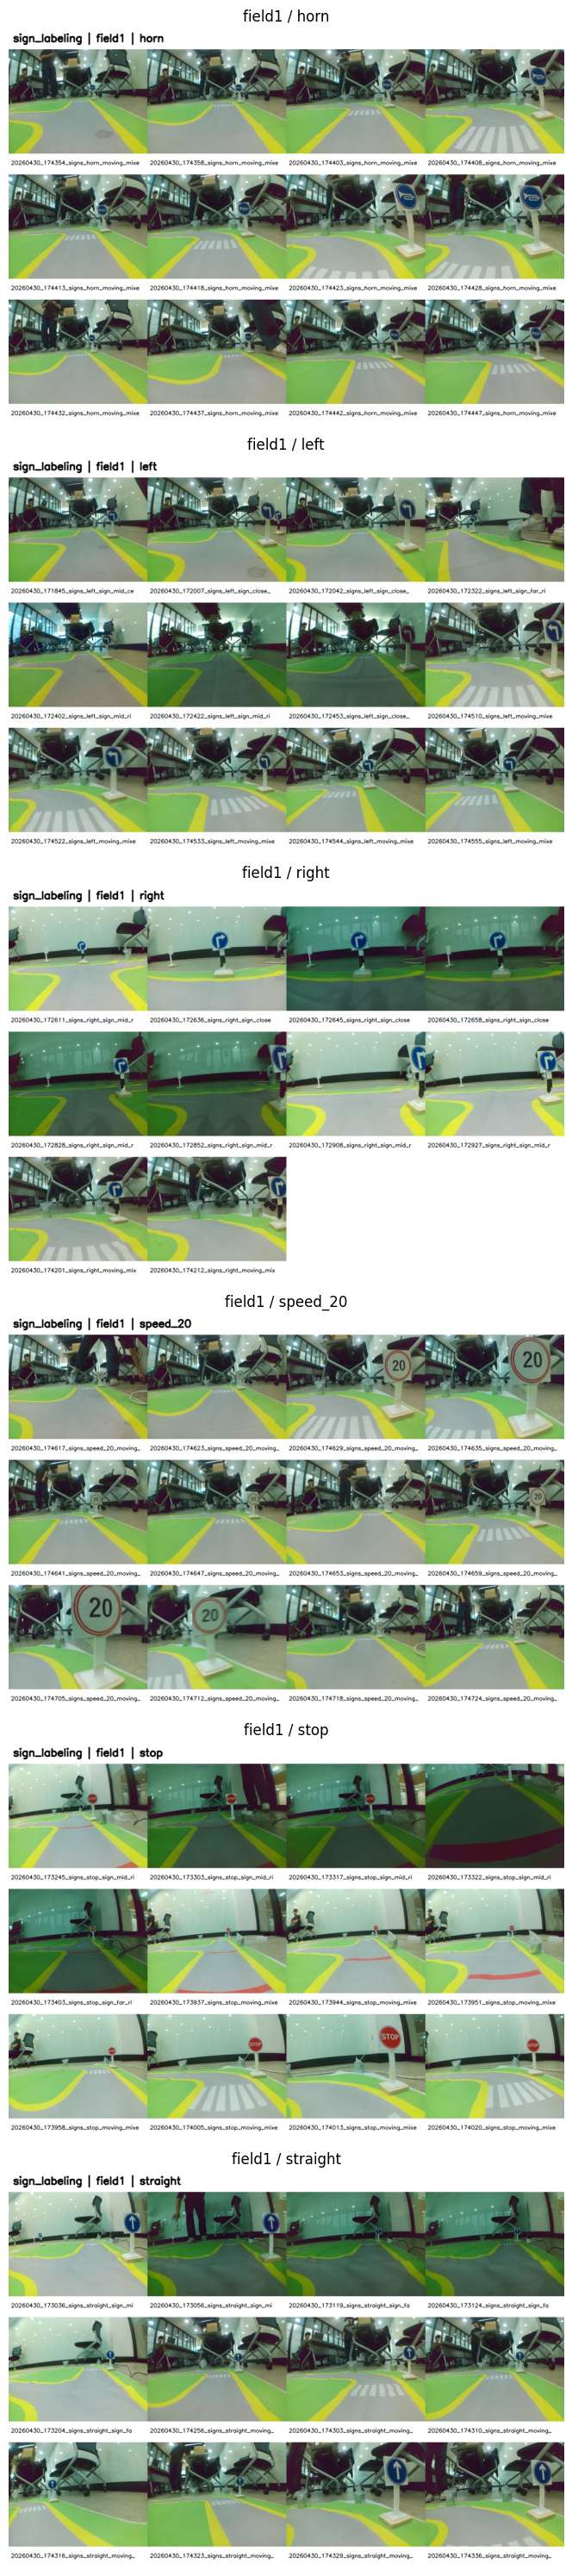

In [6]:
def evenly_spaced_sample(df, n):
    if len(df) <= n:
        return df.copy()
    idx = np.linspace(0, len(df) - 1, n).round().astype(int)
    return df.iloc[idx].copy()


def make_grid(paths, title, out_path, cols=4, thumb_w=320):
    imgs = []
    labels = []
    for p in paths:
        img = cv2_imread_color(p)
        if img is None:
            continue
        h, w = img.shape[:2]
        scale = thumb_w / w
        thumb = cv2.resize(img, (thumb_w, int(h * scale)), interpolation=cv2.INTER_AREA)
        imgs.append(thumb)
        labels.append(Path(p).name)

    if not imgs:
        return None

    rows_n = int(np.ceil(len(imgs) / cols))
    thumb_h = max(im.shape[0] for im in imgs)
    canvas = np.full((rows_n * (thumb_h + 48) + 50, cols * thumb_w, 3), 255, dtype=np.uint8)

    cv2.putText(canvas, title[:120], (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2, cv2.LINE_AA)
    for i, (img, label) in enumerate(zip(imgs, labels)):
        r = i // cols
        c = i % cols
        y = 50 + r * (thumb_h + 48)
        x = c * thumb_w
        canvas[y:y + img.shape[0], x:x + img.shape[1]] = img
        cv2.putText(canvas, label[:38], (x + 5, y + thumb_h + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 0, 0), 1, cv2.LINE_AA)

    cv2_imwrite(out_path, canvas)
    return out_path


grid_rows = []
group_cols = ['candidate_type', 'source', 'folder_label']
for key, group in manifest_meta_df.sort_values('file_name').groupby(group_cols, dropna=False):
    candidate_type, source, folder_label = key
    sample = evenly_spaced_sample(group, SAMPLES_PER_GROUP)
    safe_name = f'{candidate_type}_{source}_{folder_label}'.replace('/', '_').replace(' ', '_')
    out_path = GRID_DIR / f'{safe_name}.jpg'
    result = make_grid(sample['absolute_path'].tolist(), f'{candidate_type} | {source} | {folder_label}', out_path)
    grid_rows.append({
        'candidate_type': candidate_type,
        'source': source,
        'folder_label': folder_label,
        'sample_count': len(sample),
        'grid_path': str(result) if result else '',
    })

grid_df = pd.DataFrame(grid_rows)
GRID_INDEX_CSV = TABLE_DIR / 'sample_grid_index.csv'
grid_df.to_csv(win_long_path(GRID_INDEX_CSV), index=False, encoding='utf-8-sig')
display(grid_df)
print('saved:', GRID_INDEX_CSV)

# 먼저 표지판 6클래스 일부를 노트북 안에서도 보여준다.
show_rows = grid_df[grid_df['candidate_type'] == 'sign_labeling'].head(6)
fig, axes = plt.subplots(len(show_rows), 1, figsize=(14, 5 * len(show_rows)))
if len(show_rows) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, show_rows.iterrows()):
    img = cv2.cvtColor(cv2_imread_color(row['grid_path']), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{row['source']} / {row['folder_label']}")
plt.tight_layout()
plt.show()

## 6. 라벨링 후보 manifest 분리

다음 노트북에서는 이 CSV를 기반으로 Roboflow 업로드용 이미지 pack을 만든다.

분리 기준:

- `sign_labeling_manifest.csv`: 직접 bbox 라벨링할 표지판 6클래스 후보
- `negative_background_manifest.csv`: 일부만 negative image로 섞을 후보
- `traffic_reference_manifest.csv`: 이번 표지판 YOLO에는 넣지 않고, 신호등 HSV/별도 검증용 참고 데이터

In [7]:
sign_labeling_df = manifest_meta_df[manifest_meta_df['candidate_type'] == 'sign_labeling'].copy()
negative_df = manifest_meta_df[manifest_meta_df['candidate_type'] == 'negative_background'].copy()
traffic_df = manifest_meta_df[manifest_meta_df['candidate_type'] == 'traffic_reference'].copy()

SIGN_LABELING_CSV = TABLE_DIR / 'sign_labeling_manifest.csv'
NEGATIVE_CSV = TABLE_DIR / 'negative_background_manifest.csv'
TRAFFIC_CSV = TABLE_DIR / 'traffic_reference_manifest.csv'

sign_labeling_df.to_csv(win_long_path(SIGN_LABELING_CSV), index=False, encoding='utf-8-sig')
negative_df.to_csv(win_long_path(NEGATIVE_CSV), index=False, encoding='utf-8-sig')
traffic_df.to_csv(win_long_path(TRAFFIC_CSV), index=False, encoding='utf-8-sig')

print('sign_labeling:', len(sign_labeling_df), SIGN_LABELING_CSV)
print('negative_background:', len(negative_df), NEGATIVE_CSV)
print('traffic_reference:', len(traffic_df), TRAFFIC_CSV)

display(sign_labeling_df.groupby(['target_class', 'source']).size().unstack(fill_value=0).loc[SIGN_CLASSES])
display(negative_df.groupby(['source', 'folder_label']).size().reset_index(name='count'))
display(traffic_df.groupby(['source', 'folder_label']).size().reset_index(name='count'))

sign_labeling: 4881 ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\00_data_audit\tables\sign_labeling_manifest.csv
negative_background: 819 ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\00_data_audit\tables\negative_background_manifest.csv
traffic_reference: 656 ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\00_data_audit\tables\traffic_reference_manifest.csv


source,field1,field2
target_class,,
left,556,477
right,547,412
straight,329,386
horn,244,457
stop,357,395
speed_20,306,415


,source,folder_label,count
0,field1,background,500
1,field2,background,319


,source,folder_label,count
0,field1,green,205
1,field1,red,201
2,field2,green,108
3,field2,red,142


## 7. 실행 결과 메모

00 데이터 구조 파악 결과, field1/field2 표지판 데이터는 YOLO 라벨링으로 넘어갈 수 있는 상태임.

### 데이터 수량

- 전체 audit 대상: 6,356장
- 표지판 6클래스 라벨링 후보: 4,881장
- negative/background 후보: 819장
- 신호등 참고 데이터: 656장

표지판 6클래스 후보 수:

| class | field1 | field2 | total |
|---|---:|---:|---:|
| left | 556 | 477 | 1,033 |
| right | 547 | 412 | 959 |
| straight | 329 | 386 | 715 |
| horn | 244 | 457 | 701 |
| stop | 357 | 395 | 752 |
| speed_20 | 306 | 415 | 721 |

클래스별 편차는 있지만, 가장 적은 `horn`도 701장이라 Roboflow 라벨링을 시작하기에는 충분함.

### 이미지 무결성

- 읽기 성공: 6,181장
- 읽기 실패: 175장
- 실패 파일은 전부 0바이트 파일임.
- 실패 분포:
  - `field1/signs/right`: 90장
  - `field1/signs/background`: 85장

따라서 다음 01 pack 생성 단계에서는 `read_ok=True`만 사용해야 함.  
0바이트 파일은 Roboflow에 올리면 안 됨.

### 해상도

읽기 성공한 이미지는 모두 `1296x972x3`으로 확인됨.  
레인 모델과 같은 원본 카메라 해상도이므로, YOLO 학습용으로도 해상도 일관성은 좋음.

### 샘플 그리드 확인

`sample_grids`를 확인한 결과, 표지판은 대부분 오른쪽에 잘 보이고, 가까운 거리/먼 거리/곡선/교차로 배경이 섞여 있음.  
특히 field2 데이터는 실제 주행하면서 찍은 프레임이라 YOLO 학습에는 field1보다 실전성이 높음.

다만 연속 프레임이 많기 때문에 4,881장을 전부 Roboflow에 올리면 라벨링 부담이 커질 수 있음.  
다음 단계에서는 클래스별/소스별로 균형 있게 샘플링해서 Roboflow 업로드 pack을 만드는 것이 좋음.

### 다음 단계

01 노트북에서 수행할 작업:

1. `sign_labeling_manifest.csv`에서 `read_ok=True`만 필터링함.
2. 클래스별/소스별로 업로드할 이미지 수를 정함.
3. 연속 프레임 중복을 줄이되, 거리/각도/배경 다양성은 유지함.
4. negative/background 이미지를 소량 포함할지 결정함.
5. Roboflow Object Detection 프로젝트 업로드용 폴더와 zip을 생성함.

Roboflow 프로젝트 타입은 반드시 **Object Detection**으로 생성해야 함.  
클래스명은 `left`, `right`, `straight`, `horn`, `stop`, `speed_20`으로 통일함.